# Unified Synchronization Analysis - Kuramoto Order Parameter

This notebook provides a unified framework for analyzing synchronization in time series data using the Kuramoto order parameter. It supports:
- Experimental/industrial data (Parquet files)
- Lorenz attractor simulations
- Sinusoidal signals
- Synthetic coupled oscillators

In [3]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.animation import FuncAnimation
%matplotlib inline
import seaborn as sns
from scipy import stats
from scipy.signal import hilbert
import os
from pathlib import Path
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Any
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.8g}'.format

## Core Classes

In [4]:
@dataclass
class SignalPair:
    """Container for two signals to analyze for synchronization."""
    signal_a: np.ndarray
    signal_b: np.ndarray
    time: Optional[np.ndarray] = None
    name_a: str = "Signal A"
    name_b: str = "Signal B"
    sampling_rate: float = 1.0
    
    def __post_init__(self):
        if self.time is None:
            self.time = np.arange(len(self.signal_a)) / self.sampling_rate
        assert len(self.signal_a) == len(self.signal_b), "Signals must have same length"
    
    @property
    def n_samples(self) -> int:
        return len(self.signal_a)

In [5]:
class DataSource(ABC):
    """Abstract base class for data sources."""
    
    @abstractmethod
    def load(self) -> SignalPair:
        """Load and return a SignalPair for analysis."""
        pass
    
    @abstractmethod
    def get_description(self) -> str:
        """Return a human-readable description of the data source."""
        pass

In [6]:
class ParquetDataSource(DataSource):
    """Load data from Parquet files (experimental/industrial data)."""
    
    def __init__(self, file_path: str, column_a: str, column_b: str,
                 index_start: int = 0, index_end: Optional[int] = None,
                 window: int = 60, lag: Optional[int] = None,
                 sampling_rate: float = 1.0):
        self.file_path = file_path
        self.column_a = column_a
        self.column_b = column_b
        self.index_start = index_start
        self.index_end = index_end
        self.window = window
        self.lag = lag
        self.sampling_rate = sampling_rate
    
    def load(self) -> SignalPair:
        df = pd.read_parquet(self.file_path)
        
        if self.index_end is None:
            self.index_end = len(df)
        
        # Apply rolling mean to smooth
        series_a = df[self.column_a].iloc[self.index_start:self.index_end].rolling(self.window).mean()
        series_b = df[self.column_b].iloc[self.index_start:self.index_end].rolling(self.window).mean()
        
        # Remove NaN from rolling
        series_a = series_a.dropna()
        series_b = series_b.dropna()
        
        # Apply lag if specified
        if self.lag is not None:
            series_a = series_a.iloc[self.lag:].reset_index(drop=True)
            series_b = series_b.iloc[:-self.lag].reset_index(drop=True)
        
        # Center signals (remove mean)
        signal_a = (series_a - series_a.mean()).values
        signal_b = (series_b - series_b.mean()).values
        
        # Symmetrize for Hilbert transform
        signal_a = np.concatenate((signal_a[::-1], signal_a))
        signal_b = np.concatenate((signal_b[::-1], signal_b))
        
        return SignalPair(
            signal_a=signal_a,
            signal_b=signal_b,
            name_a=self.column_a,
            name_b=self.column_b,
            sampling_rate=self.sampling_rate
        )
    
    def get_description(self) -> str:
        return f"Parquet: {self.file_path} [{self.column_a} vs {self.column_b}]"

In [7]:
class LorenzDataSource(DataSource):
    """Generate Lorenz attractor time series."""
    
    def __init__(self, a: float = 10.0, b: float = 28.0, c: float = 8.0/3.0,
                 dt: float = 0.01, initial_values_1: List[float] = None,
                 initial_values_2: List[float] = None, iterations: int = 1000,
                 variable: str = 'x', sampling_rate: float = 100.0):
        self.a, self.b, self.c = a, b, c
        self.dt = dt
        self.initial_values_1 = initial_values_1 or [0.01, 0, 0.3]
        self.initial_values_2 = initial_values_2 or [0.2, 0.1, 0.4]
        self.iterations = iterations
        self.variable = variable
        self.sampling_rate = sampling_rate
    
    def _generate(self, initial_values: List[float]) -> np.ndarray:
        x, y, z = [initial_values[0]], [initial_values[1]], [initial_values[2]]
        for _ in range(self.iterations):
            dxdt = self.a * (y[-1] - x[-1])
            dydt = x[-1] * (self.b - z[-1]) - y[-1]
            dzdt = x[-1] * y[-1] - self.c * z[-1]
            x.append(x[-1] + self.dt * dxdt)
            y.append(y[-1] + self.dt * dydt)
            z.append(z[-1] + self.dt * dzdt)
        return np.array({'x': x, 'y': y, 'z': z}[self.variable])
    
    def load(self) -> SignalPair:
        signal_a = self._generate(self.initial_values_1)
        signal_b = self._generate(self.initial_values_2)
        
        return SignalPair(
            signal_a=signal_a,
            signal_b=signal_b,
            name_a=f"Lorenz {self.variable} (IC1)",
            name_b=f"Lorenz {self.variable} (IC2)",
            sampling_rate=self.sampling_rate
        )
    
    def get_description(self) -> str:
        return f"Lorenz attractor: a={self.a}, b={self.b}, c={self.c:.3f}, var={self.variable}"

In [8]:
class SinusoidDataSource(DataSource):
    """Generate sinusoidal signals with controllable phase/frequency."""
    
    def __init__(self, ph0_a: float = 0, ph0_b: float = 0,
                 frq_a: float = 1, frq_b: float = 1,
                 pers: int = 1, delay_a: float = 0, delay_b: float = 0,
                 iterations: int = 1000, sampling_rate: float = 1.0):
        self.ph0_a, self.ph0_b = ph0_a, ph0_b
        self.frq_a, self.frq_b = frq_a, frq_b
        self.pers = pers
        self.delay_a, self.delay_b = delay_a, delay_b
        self.iterations = iterations
        self.sampling_rate = sampling_rate
    
    def _generate(self, ph0: float, frq: float, delay: float) -> np.ndarray:
        t = np.linspace(0, 2*np.pi*self.pers, self.iterations)
        return np.sin((t - delay) + ph0) * np.cos(frq * (t - delay) + ph0)
    
    def load(self) -> SignalPair:
        signal_a = self._generate(self.ph0_a, self.frq_a, self.delay_a)
        signal_b = self._generate(self.ph0_b, self.frq_b, self.delay_b)
        
        return SignalPair(
            signal_a=signal_a,
            signal_b=signal_b,
            name_a=f"Sin phi={self.ph0_a}, f={self.frq_a}, d={self.delay_a}",
            name_b=f"Sin phi={self.ph0_b}, f={self.frq_b}, d={self.delay_b}",
            sampling_rate=self.sampling_rate
        )
    
    def get_description(self) -> str:
        return f"Sinusoids: phi_1={self.ph0_a}, f_1={self.frq_a}, d_1={self.delay_a} | phi_2={self.ph0_b}, f_2={self.frq_b}, d_2={self.delay_b}"

In [9]:
class CoupledOscillatorDataSource(DataSource):
    """Generate synthetic coupled oscillators (Kuramoto model)."""
    
    def __init__(self, n_oscillators: int = 2, coupling_strength: float = 0.5,
                 natural_freqs: Optional[np.ndarray] = None,
                 dt: float = 0.01, duration: float = 100.0,
                 noise_std: float = 0.0, sampling_rate: float = 100.0):
        self.n_oscillators = n_oscillators
        self.coupling_strength = coupling_strength
        self.natural_freqs = np.array(natural_freqs) if natural_freqs is not None else np.random.normal(1.0, 0.1, n_oscillators)
        self.dt = dt
        self.duration = duration
        self.noise_std = noise_std
        self.sampling_rate = sampling_rate
    
    def load(self) -> SignalPair:
        n_steps = int(self.duration / self.dt)
        phases = np.random.uniform(0, 2*np.pi, self.n_oscillators)
        
        # Store phase trajectories
        phase_history = np.zeros((n_steps, self.n_oscillators))
        
        for i in range(n_steps):
            phase_history[i] = phases
            # Kuramoto model
            for j in range(self.n_oscillators):
                coupling = 0
                for k in range(self.n_oscillators):
                    if j != k:
                        coupling += np.sin(phases[k] - phases[j])
                dphase = self.natural_freqs[j] + self.coupling_strength * coupling / (self.n_oscillators - 1)
                if self.noise_std > 0:
                    dphase += np.random.normal(0, self.noise_std)
                phases[j] += dphase * self.dt
        
        # Convert to signals (cosine of phase)
        signal_a = np.cos(phase_history[:, 0])
        signal_b = np.cos(phase_history[:, 1])
        
        return SignalPair(
            signal_a=signal_a,
            signal_b=signal_b,
            name_a=f"Oscillator 1 (omega={self.natural_freqs[0]:.2f})",
            name_b=f"Oscillator 2 (omega={self.natural_freqs[1]:.2f})",
            sampling_rate=self.sampling_rate
        )
    
    def get_description(self) -> str:
        return f"Coupled oscillators: K={self.coupling_strength}, omega={self.natural_freqs}"

## Analysis Engine

In [10]:
class SynchronizationAnalyzer:
    """Core analysis engine for Kuramoto order parameter computation."""
    
    def __init__(self, signal_pair: SignalPair):
        self.signal_pair = signal_pair
        self.hilbert_a = None
        self.hilbert_b = None
        self.phase_a = None
        self.phase_b = None
        self.amplitude_a = None
        self.amplitude_b = None
        self.order_parameter = None
        self.phase_diff = None
    
    def compute_hilbert_transform(self) -> Tuple[np.ndarray, np.ndarray]:
        """Compute analytic signals via Hilbert transform."""
        self.hilbert_a = hilbert(self.signal_pair.signal_a)
        self.hilbert_b = hilbert(self.signal_pair.signal_b)
        
        self.amplitude_a = np.abs(self.hilbert_a)
        self.amplitude_b = np.abs(self.hilbert_b)
        
        self.phase_a = np.angle(self.hilbert_a)
        self.phase_b = np.angle(self.hilbert_b)
        
        return self.hilbert_a, self.hilbert_b
    
    def compute_order_parameter(self) -> np.ndarray:
        """Compute Kuramoto order parameter R(t) = |⟨e^(iphi)⟩|."""
        if self.phase_a is None or self.phase_b is None:
            self.compute_hilbert_transform()
        
        # Complex phase vectors
        z_a = np.exp(1j * self.phase_a)
        z_b = np.exp(1j * self.phase_b)
        
        # Order parameter: magnitude of mean phase vector
        self.order_parameter = np.abs((z_a + z_b) / 2)
        self.phase_diff = np.angle(z_a / z_b)  # Phase difference
        
        return self.order_parameter
    
    def compute_sliding_order_parameter(self, window: int = 50) -> np.ndarray:
        """Compute sliding window order parameter."""
        if self.order_parameter is None:
            self.compute_order_parameter()
        
        # Moving average
        return pd.Series(self.order_parameter).rolling(window, center=True).mean().values
    
    def get_summary_stats(self) -> Dict[str, float]:
        """Get summary statistics."""
        if self.order_parameter is None:
            self.compute_order_parameter()
        
        return {
            'mean_R': np.mean(self.order_parameter),
            'std_R': np.std(self.order_parameter),
            'max_R': np.max(self.order_parameter),
            'min_R': np.min(self.order_parameter),
            'mean_phase_diff': np.mean(self.phase_diff),
            'std_phase_diff': np.std(self.phase_diff),
            'sync_ratio': np.mean(self.order_parameter > 0.8),
        }

## Visualization

In [11]:
class SynchronizationVisualizer:
    """Visualization tools for synchronization analysis."""
    
    def __init__(self, analyzer: SynchronizationAnalyzer, figsize: Tuple[int, int] = (15, 10)):
        self.analyzer = analyzer
        self.figsize = figsize
    
    def plot_signals(self, ax=None, n_samples: Optional[int] = None):
        """Plot raw signals."""
        if ax is None:
            fig, ax = plt.subplots(figsize=self.figsize)
        
        sig_a = self.analyzer.signal_pair.signal_a
        sig_b = self.analyzer.signal_pair.signal_b
        
        if n_samples:
            sig_a = sig_a[:n_samples]
            sig_b = sig_b[:n_samples]
        
        time = np.arange(len(sig_a)) / self.analyzer.signal_pair.sampling_rate
        
        ax.plot(time, sig_a, label=self.analyzer.signal_pair.name_a, alpha=0.7)
        ax.plot(time, sig_b, label=self.analyzer.signal_pair.name_b, alpha=0.7)
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')
        ax.set_title('Raw Signals')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        return ax
    
    def plot_hilbert_components(self, ax=None):
        """Plot Hilbert transform components (real vs imaginary)."""
        if ax is None:
            fig, axes = plt.subplots(1, 2, figsize=self.figsize)
        else:
            axes = ax if isinstance(ax, (list, np.ndarray)) else [ax]
        
        if self.analyzer.hilbert_a is None:
            self.analyzer.compute_hilbert_transform()
        
        for i, (hilbert, name) in enumerate([(self.analyzer.hilbert_a, self.analyzer.signal_pair.name_a),
                                            (self.analyzer.hilbert_b, self.analyzer.signal_pair.name_b)]):
            ax = axes[i] if i < len(axes) else axes[0]
            ax.plot(hilbert.real, hilbert.imag, ',', alpha=0.5, markersize=1)
            ax.set_xlabel('Real')
            ax.set_ylabel('Imaginary')
            ax.set_title(f'Analytic Signal: {name}')
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
        
        return axes
    
    def plot_phases(self, ax=None):
        """Plot instantaneous phases."""
        if ax is None:
            fig, ax = plt.subplots(figsize=self.figsize)
        
        if self.analyzer.phase_a is None:
            self.analyzer.compute_hilbert_transform()
        
        time = np.arange(len(self.analyzer.phase_a)) / self.analyzer.signal_pair.sampling_rate
        
        ax.plot(time, self.analyzer.phase_a, label=self.analyzer.signal_pair.name_a, alpha=0.7)
        ax.plot(time, self.analyzer.phase_b, label=self.analyzer.signal_pair.name_b, alpha=0.7)
        ax.set_xlabel('Time')
        ax.set_ylabel('Phase (rad)')
        ax.set_title('Instantaneous Phases')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        return ax
    
    def plot_phase_portrait(self, ax=None):
        """Plot phases on unit circle."""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 8))
        
        if self.analyzer.phase_a is None:
            self.analyzer.compute_hilbert_transform()
        
        # Unit circle
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(np.cos(theta), np.sin(theta), 'k-', alpha=0.3, linewidth=1)
        
        # Phase points
        ax.plot(np.cos(self.analyzer.phase_a), np.sin(self.analyzer.phase_a), 
                'o', label=self.analyzer.signal_pair.name_a, alpha=0.6, markersize=3)
        ax.plot(np.cos(self.analyzer.phase_b), np.sin(self.analyzer.phase_b), 
                '*', label=self.analyzer.signal_pair.name_b, alpha=0.6, markersize=5)
        
        ax.set_aspect('equal')
        ax.set_xlabel('cos(phi)')
        ax.set_ylabel('sin(phi)')
        ax.set_title('Phase Portrait on Unit Circle')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        
        return ax
    
    def plot_order_parameter(self, ax=None, sliding_window: Optional[int] = None):
        """Plot Kuramoto order parameter over time."""
        if ax is None:
            fig, ax = plt.subplots(figsize=self.figsize)
        
        if self.analyzer.order_parameter is None:
            self.analyzer.compute_order_parameter()
        
        time = np.arange(len(self.analyzer.order_parameter)) / self.analyzer.signal_pair.sampling_rate
        
        ax.plot(time, self.analyzer.order_parameter, 'b-', alpha=0.5, label='R(t)')
        
        if sliding_window:
            sliding = self.analyzer.compute_sliding_order_parameter(sliding_window)
            ax.plot(time, sliding, 'r-', linewidth=2, label=f'Sliding (w={sliding_window})')
        
        ax.axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='Sync threshold (0.8)')
        ax.set_xlabel('Time')
        ax.set_ylabel('Order Parameter R(t)')
        ax.set_title('Kuramoto Order Parameter')
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        return ax
    
    def plot_phase_difference(self, ax=None):
        """Plot phase difference over time."""
        if ax is None:
            fig, ax = plt.subplots(figsize=self.figsize)
        
        if self.analyzer.phase_diff is None:
            self.analyzer.compute_order_parameter()
        
        time = np.arange(len(self.analyzer.phase_diff)) / self.analyzer.signal_pair.sampling_rate
        
        ax.plot(time, self.analyzer.phase_diff, 'g-', alpha=0.7)
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        ax.axhline(y=np.pi, color='r', linestyle='--', alpha=0.5, label='pi')
        ax.axhline(y=-np.pi, color='r', linestyle='--', alpha=0.5, label='-pi')
        ax.set_xlabel('Time')
        ax.set_ylabel('Phase Difference (rad)')
        ax.set_title('Phase Difference phi_1 - phi_2')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        return ax
    
    def create_dashboard(self, sliding_window: int = 50, n_signal_samples: int = 500):
        """Create a comprehensive dashboard."""
        fig = plt.figure(figsize=(20, 16))
        
        # Grid layout
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
        
        # Raw signals
        ax1 = fig.add_subplot(gs[0, 0])
        self.plot_signals(ax1, n_samples=n_signal_samples)
        
        # Hilbert components
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[0, 2])
        self.plot_hilbert_components([ax2, ax3])
        
        # Phases
        ax4 = fig.add_subplot(gs[1, 0])
        self.plot_phases(ax4)
        
        # Phase portrait
        ax5 = fig.add_subplot(gs[1, 1])
        self.plot_phase_portrait(ax5)
        
        # Order parameter
        ax6 = fig.add_subplot(gs[1, 2])
        self.plot_order_parameter(ax6, sliding_window=sliding_window)
        
        # Phase difference
        ax7 = fig.add_subplot(gs[2, 0])
        self.plot_phase_difference(ax7)
        
        # Summary stats
        ax8 = fig.add_subplot(gs[2, 1:])
        ax8.axis('off')
        stats = self.analyzer.get_summary_stats()
        stats_text = '\n'.join([f'{k}: {v:.4f}' for k, v in stats.items()])
        ax8.text(0.1, 0.9, stats_text, transform=ax8.transAxes, fontsize=12,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax8.set_title('Summary Statistics')
        
        # Main title
        fig.suptitle(f'Synchronization Analysis: {self.analyzer.signal_pair.name_a} vs {self.analyzer.signal_pair.name_b}', 
                   fontsize=16, y=0.98)
        
        return fig
    
    def animate_phases(self, interval: int = 50, trail_length: int = 50):
        """Create animation of phases on unit circle."""
        if self.analyzer.phase_a is None:
            self.analyzer.compute_hilbert_transform()
        
        fig, ax = plt.subplots(figsize=(8, 8))
        
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(np.cos(theta), np.sin(theta), 'k-', alpha=0.3)
        ax.set_aspect('equal')
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_xlabel('cos(phi)')
        ax.set_ylabel('sin(phi)')
        ax.set_title('Phase Evolution Animation')
        
        # Initialize points
        point_a, = ax.plot([], [], 'ro', markersize=10, label=self.analyzer.signal_pair.name_a)
        point_b, = ax.plot([], [], 'bs', markersize=10, label=self.analyzer.signal_pair.name_b)
        trail_a, = ax.plot([], [], 'r-', alpha=0.3, linewidth=1)
        trail_b, = ax.plot([], [], 'b-', alpha=0.3, linewidth=1)
        
        ax.legend()
        
        def init():
            point_a.set_data([], [])
            point_b.set_data([], [])
            trail_a.set_data([], [])
            trail_b.set_data([], [])
            return point_a, point_b, trail_a, trail_b
        
        def animate(frame):
            point_a.set_data([np.cos(self.analyzer.phase_a[frame])], [np.sin(self.analyzer.phase_a[frame])])
            point_b.set_data([np.cos(self.analyzer.phase_b[frame])], [np.sin(self.analyzer.phase_b[frame])])
            
            start = max(0, frame - trail_length)
            trail_a.set_data(np.cos(self.analyzer.phase_a[start:frame]), 
                           np.sin(self.analyzer.phase_a[start:frame]))
            trail_b.set_data(np.cos(self.analyzer.phase_b[start:frame]), 
                           np.sin(self.analyzer.phase_b[start:frame]))
            
            return point_a, point_b, trail_a, trail_b
        
        anim = FuncAnimation(fig, animate, frames=len(self.analyzer.phase_a),
                           init_func=init, interval=interval, blit=True)
        
        plt.close()
        return anim

## High-Level Pipeline

In [12]:
class SynchronizationPipeline:
    """End-to-end pipeline for synchronization analysis."""
    
    def __init__(self, data_source: DataSource):
        self.data_source = data_source
        self.signal_pair = None
        self.analyzer = None
        self.visualizer = None
    
    def run(self) -> 'SynchronizationPipeline':
        """Execute the full pipeline."""
        print(f"Loading data: {self.data_source.get_description()}")
        self.signal_pair = self.data_source.load()
        print(f"  Signal A: {self.signal_pair.name_a} ({self.signal_pair.n_samples} samples)")
        print(f"  Signal B: {self.signal_pair.name_b} ({self.signal_pair.n_samples} samples)")
        
        self.analyzer = SynchronizationAnalyzer(self.signal_pair)
        self.visualizer = SynchronizationVisualizer(self.analyzer)
        
        print("Computing Hilbert transforms...")
        self.analyzer.compute_hilbert_transform()
        
        print("Computing Kuramoto order parameter...")
        self.analyzer.compute_order_parameter()
        
        stats = self.analyzer.get_summary_stats()
        print(f"  Mean R: {stats['mean_R']:.4f}")
        print(f"  Sync ratio (R>0.8): {stats['sync_ratio']:.2%}")
        
        return self
    
    def plot_dashboard(self, **kwargs):
        """Create and show dashboard."""
        if self.visualizer is None:
            self.run()
        return self.visualizer.create_dashboard(**kwargs)
    
    def animate(self, **kwargs):
        """Create phase animation."""
        if self.visualizer is None:
            self.run()
        return self.visualizer.animate_phases(**kwargs)
    
    def get_stats(self) -> Dict[str, float]:
        """Get analysis statistics."""
        if self.analyzer is None:
            self.run()
        return self.analyzer.get_summary_stats()

## Example Usage

### 1. Experimental/Industrial Data (Parquet)

In [13]:
# Example: Load industrial sensor data
# pipeline = SynchronizationPipeline(
#     ParquetDataSource(
#         file_path='data/datos_peso_01_11_2021_07_11_2021.pqt',
#         column_a='FormacionMWEntT11TempPV',
#         column_b='FormacionMWSalT12TempPV',
#         index_start=80900,
#         index_end=82700,
#         window=60,
#         lag=18600/int(df['FormacionVelocidad'].iloc[80900:82700].mean())
#     )
# ).run()
# pipeline.plot_dashboard()

### 2. Lorenz Attractor

Loading data: Lorenz attractor: a=10.0, b=28.0, c=2.667, var=x
  Signal A: Lorenz x (IC1) (1001 samples)
  Signal B: Lorenz x (IC2) (1001 samples)
Computing Hilbert transforms...
Computing Kuramoto order parameter...
  Mean R: 0.6860
  Sync ratio (R>0.8): 44.16%


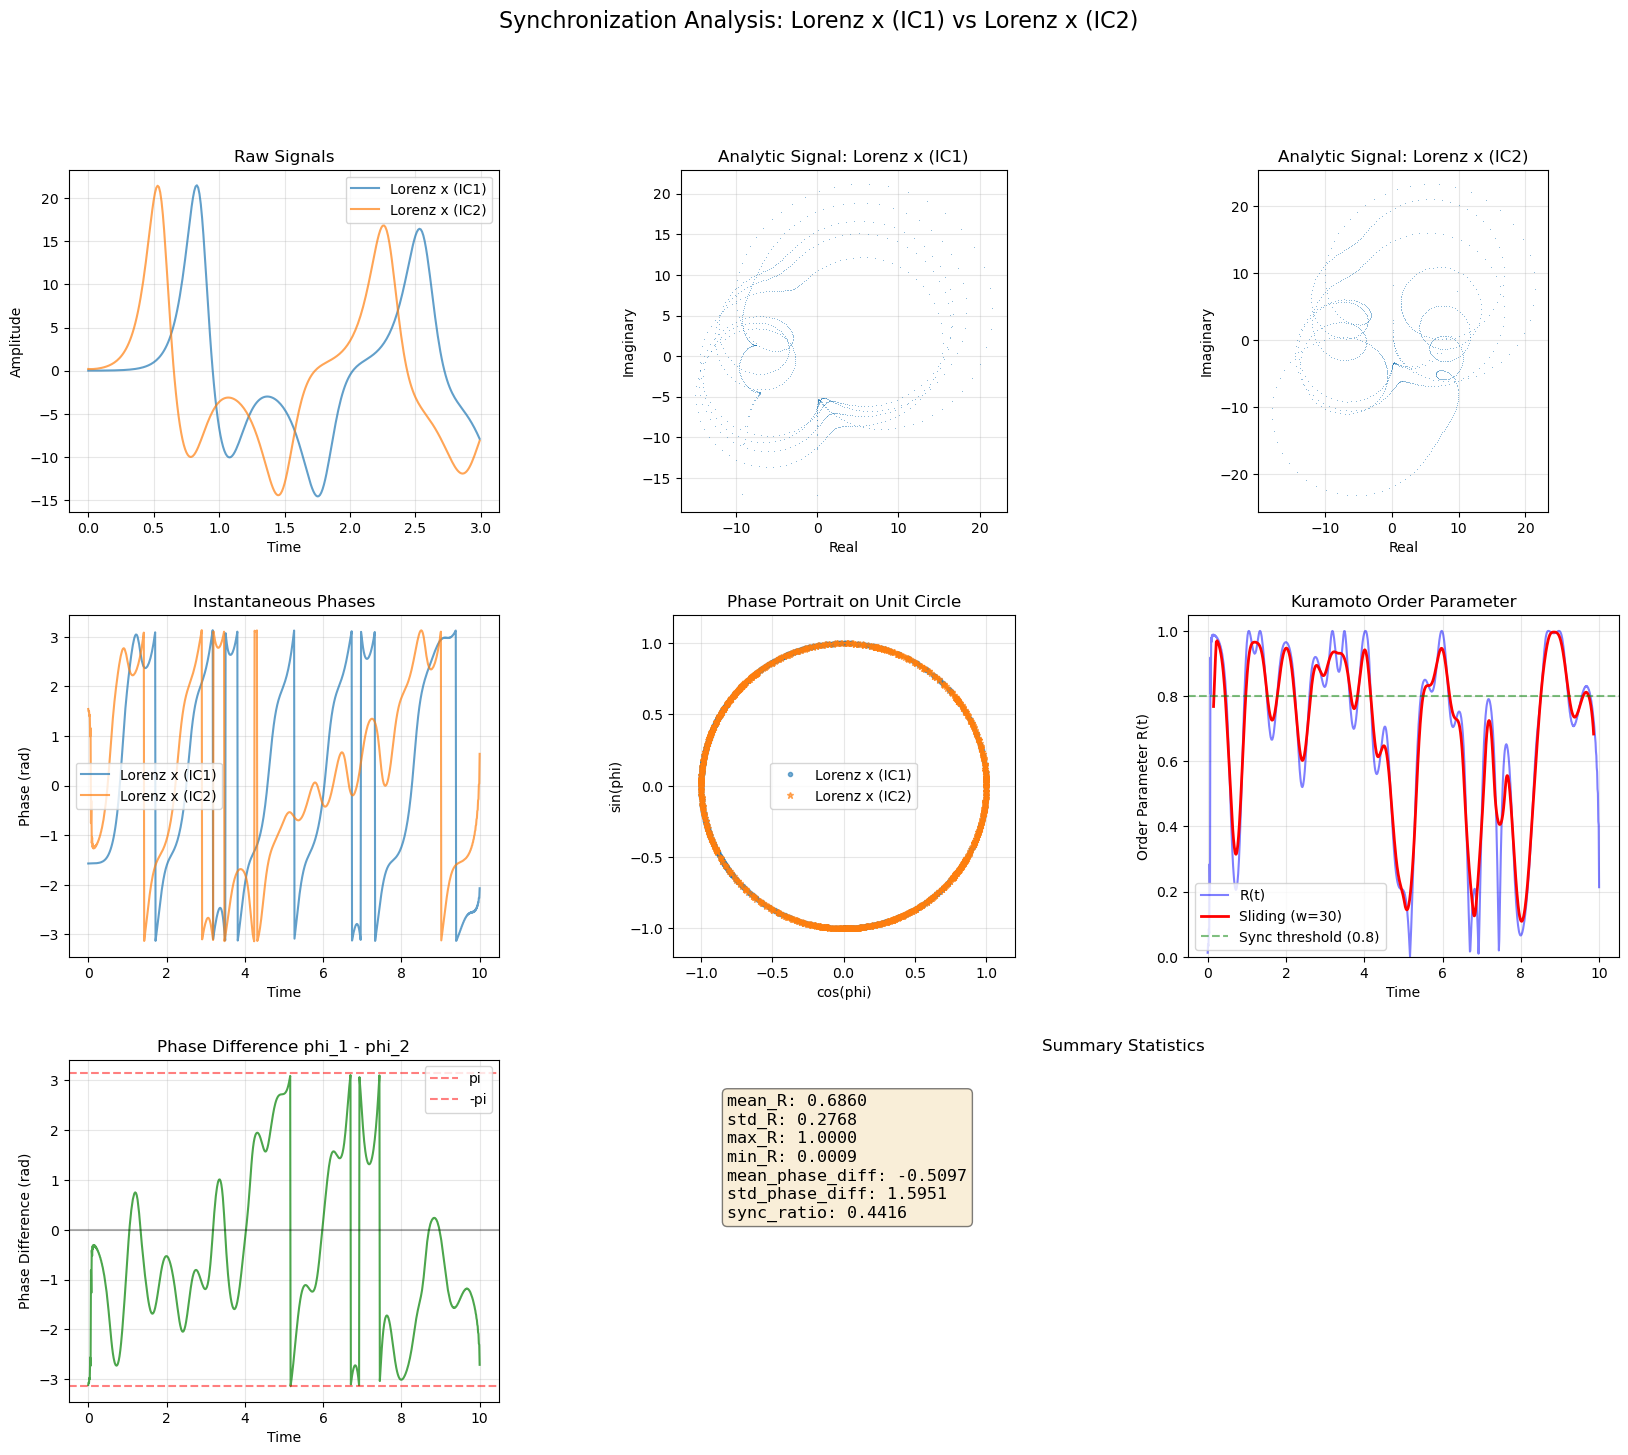

In [14]:
# Lorenz attractor with two nearby initial conditions
lorenz_source = LorenzDataSource(
    a=10.0, b=28.0, c=8.0/3.0, dt=0.01,
    initial_values_1=[0.01, 0, 0.3],
    initial_values_2=[0.2, 0.1, 0.4],
    iterations=1000,
    variable='x',
    sampling_rate=100.0
)

lorenz_pipeline = SynchronizationPipeline(lorenz_source).run()
lorenz_pipeline.plot_dashboard(sliding_window=30, n_signal_samples=300)

### 3. Sinusoidal Signals

Loading data: Sinusoids: phi_1=0, f_1=2, d_1=0 | phi_2=0, f_2=2, d_2=3
  Signal A: Sin phi=0, f=2, d=0 (1000 samples)
  Signal B: Sin phi=0, f=2, d=3 (1000 samples)
Computing Hilbert transforms...
Computing Kuramoto order parameter...
  Mean R: 0.1800
  Sync ratio (R>0.8): 4.40%


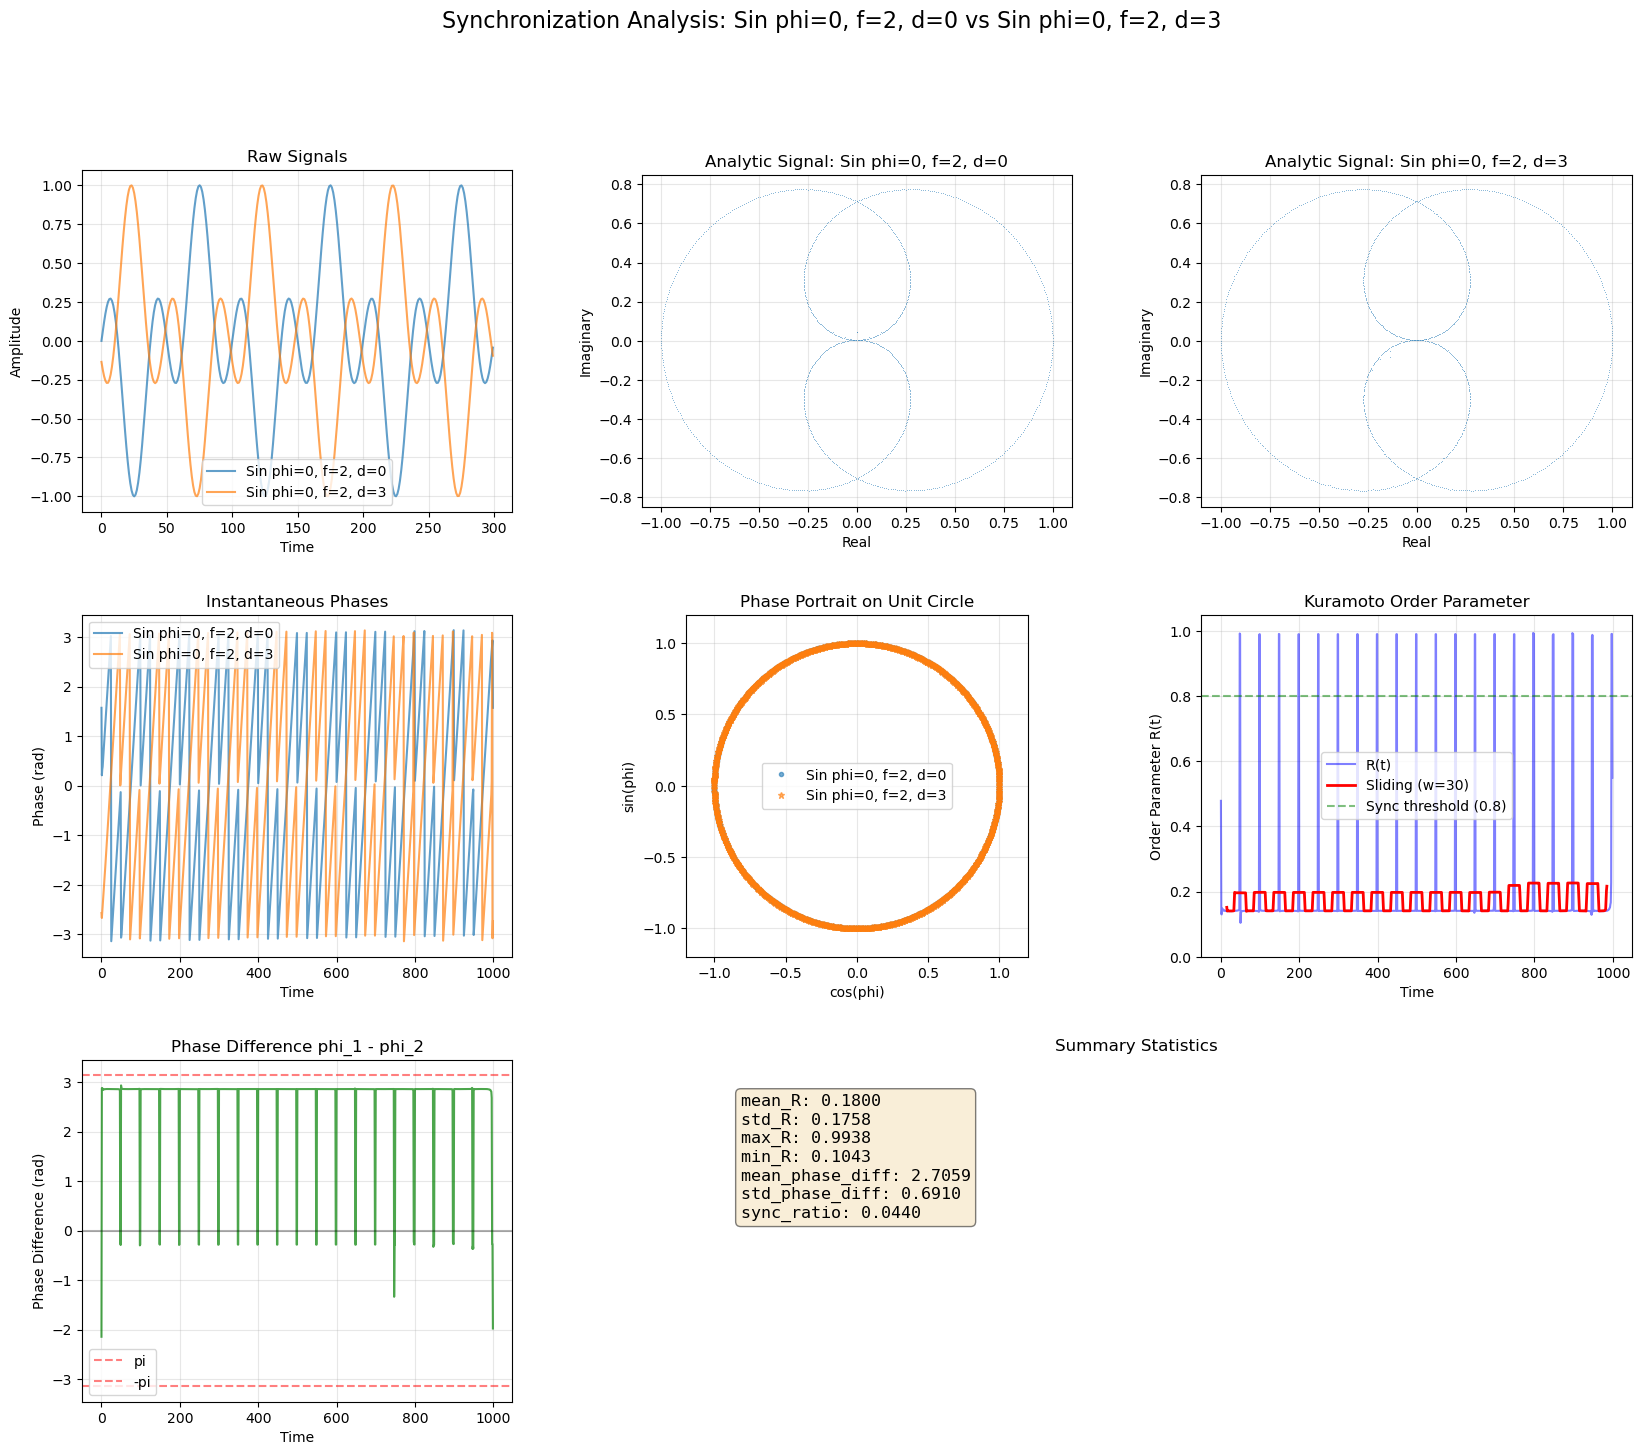

In [15]:
# Two sinusoids with phase difference
sin_source = SinusoidDataSource(
    ph0_a=0, ph0_b=0,
    frq_a=2, frq_b=2,
    pers=10, delay_a=0, delay_b=3,
    iterations=1000,
    sampling_rate=1.0
)

sin_pipeline = SynchronizationPipeline(sin_source).run()
sin_pipeline.plot_dashboard(sliding_window=30, n_signal_samples=300)

### 4. Coupled Oscillators (Kuramoto Model)

Loading data: Coupled oscillators: K=0.8, omega=[1.   1.05]
  Signal A: Oscillator 1 (omega=1.00) (5000 samples)
  Signal B: Oscillator 2 (omega=1.05) (5000 samples)
Computing Hilbert transforms...
Computing Kuramoto order parameter...
  Mean R: 0.9986
  Sync ratio (R>0.8): 100.00%


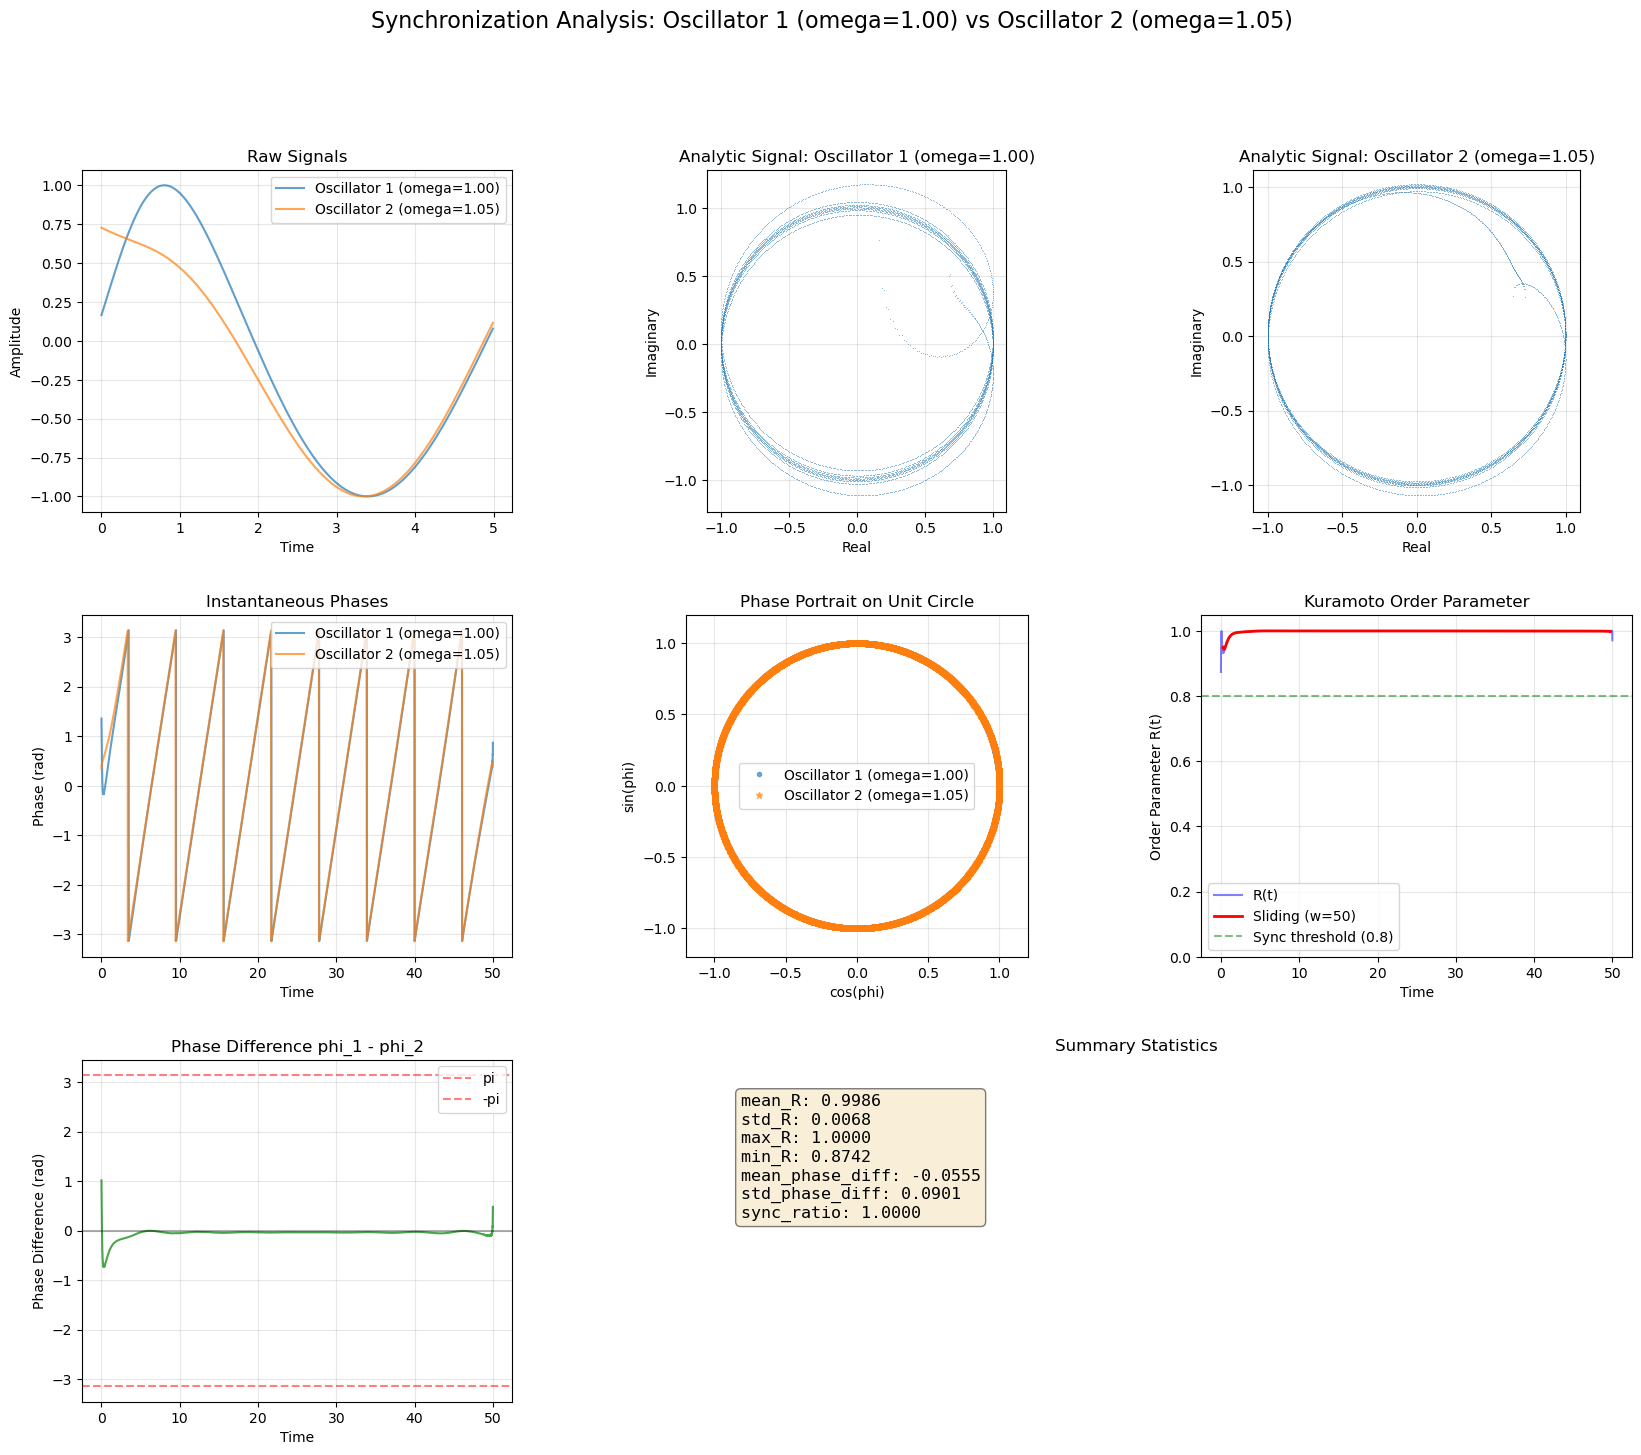

In [16]:
# Synthetic coupled oscillators
coupled_source = CoupledOscillatorDataSource(
    n_oscillators=2,
    coupling_strength=0.8,
    natural_freqs=np.array([1.0, 1.05]),
    dt=0.01,
    duration=50.0,
    noise_std=0.01,
    sampling_rate=100.0
)

coupled_pipeline = SynchronizationPipeline(coupled_source).run()
coupled_pipeline.plot_dashboard(sliding_window=50, n_signal_samples=500)

## Batch Analysis

In [17]:
def compare_data_sources(sources: List[DataSource], labels: Optional[List[str]] = None) -> pd.DataFrame:
    """Compare synchronization across multiple data sources."""
    results = []
    
    for i, source in enumerate(sources):
        label = labels[i] if labels else source.get_description()
        pipeline = SynchronizationPipeline(source).run()
        stats = pipeline.get_stats()
        stats['source'] = label
        results.append(stats)
    
    return pd.DataFrame(results)

# Example comparison
# sources = [lorenz_source, sin_source, coupled_source]
# labels = ['Lorenz', 'Sinusoids', 'Coupled Oscillators']
# comparison_df = compare_data_sources(sources, labels)
# display(comparison_df)

## Animation Example

In [18]:
# Create animation for sinusoidal case
# anim = sin_pipeline.animate(interval=30, trail_length=30)
# from IPython.display import HTML
# HTML(anim.to_jshtml())

## Export Results

In [19]:
def export_results(pipeline: SynchronizationPipeline, output_dir: str = 'results'):
    """Export analysis results to files."""
    Path(output_dir).mkdir(exist_ok=True)
    
    # Save statistics
    stats = pipeline.get_stats()
    pd.Series(stats).to_csv(f'{output_dir}/sync_stats.csv')
    
    # Save time series
    if pipeline.analyzer.order_parameter is not None:
        df = pd.DataFrame({
            'time': pipeline.analyzer.signal_pair.time[:len(pipeline.analyzer.order_parameter)],
            'R': pipeline.analyzer.order_parameter,
            'phase_diff': pipeline.analyzer.phase_diff,
            'phase_a': pipeline.analyzer.phase_a,
            'phase_b': pipeline.analyzer.phase_b,
        })
        df.to_csv(f'{output_dir}/sync_timeseries.csv', index=False)
    
    # Save dashboard
    fig = pipeline.plot_dashboard()
    fig.savefig(f'{output_dir}/sync_dashboard.png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    
    print(f"Results exported to {output_dir}/")